Rodrigo García Salado

---
### PRÁCTICA 2
---

Ponemos los imports

In [133]:
#imports

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.metrics import silhouette_score



Importamos el archivo

In [134]:
# Cargamos el archivo
data_df = pd.read_csv("stars_data.csv") 

Ahora observamos cuantos y qué tipo de datos vamos a estar tratando


In [135]:

print('The shape of the data table is:')
print('===============================')
print(data_df.shape)
print()

print('The types of the attributes are:')
print('================================')
data_df.info()

print()

print('How many missing values per attribute:')
print('======================================')
print(data_df.isnull().sum())

print()

print('Fraction of missing values per attribute:')
print('======================================')
print(data_df.isnull().mean())


The shape of the data table is:
(240, 6)

The types of the attributes are:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Temperature     240 non-null    int64  
 1   L               240 non-null    float64
 2   R               240 non-null    float64
 3   A_M             240 non-null    float64
 4   Color           240 non-null    object 
 5   Spectral_Class  240 non-null    object 
dtypes: float64(3), int64(1), object(2)
memory usage: 11.4+ KB

How many missing values per attribute:
Temperature       0
L                 0
R                 0
A_M               0
Color             0
Spectral_Class    0
dtype: int64

Fraction of missing values per attribute:
Temperature       0.0
L                 0.0
R                 0.0
A_M               0.0
Color             0.0
Spectral_Class    0.0
dtype: float64


In [136]:
SEMILLA = 100478705

# Lista de scalers a comparar
scalers = {
    'StandardScaler': StandardScaler(),
    'MinMaxScaler': MinMaxScaler(),
    'RobustScaler': RobustScaler()
}



Debemos agrupar la variable categórica, por lo que lo haremos a partir de la media de su temperatura correspondiente

In [137]:
y = data_df['Spectral_Class'] 

# Orden lógico basado en temperatura
orden_color = data_df.groupby('Color')['Temperature'].mean().sort_values().index
orden_spectral = data_df.groupby('Spectral_Class')['Temperature'].mean().sort_values().index

mapa_color = {c: i for i, c in enumerate(orden_color)}
mapa_spectral = {c: i for i, c in enumerate(orden_spectral)}

data_df['Color'] = data_df['Color'].map(mapa_color)
data_df['Spectral_Class'] = data_df['Spectral_Class'].map(mapa_spectral)

# X para clustering (quitamos la etiqueta)
X = data_df.drop(columns=['Spectral_Class'])
y_numerico = data_df['Spectral_Class']

creamos la figura para comparar

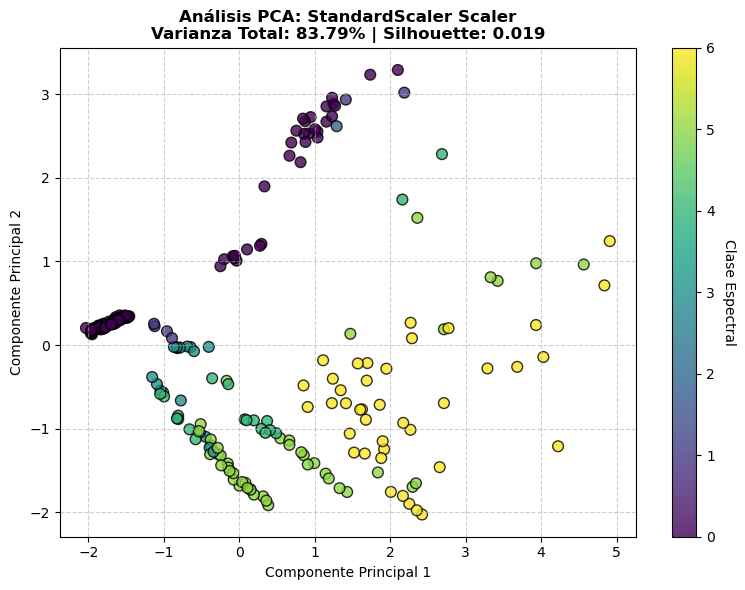

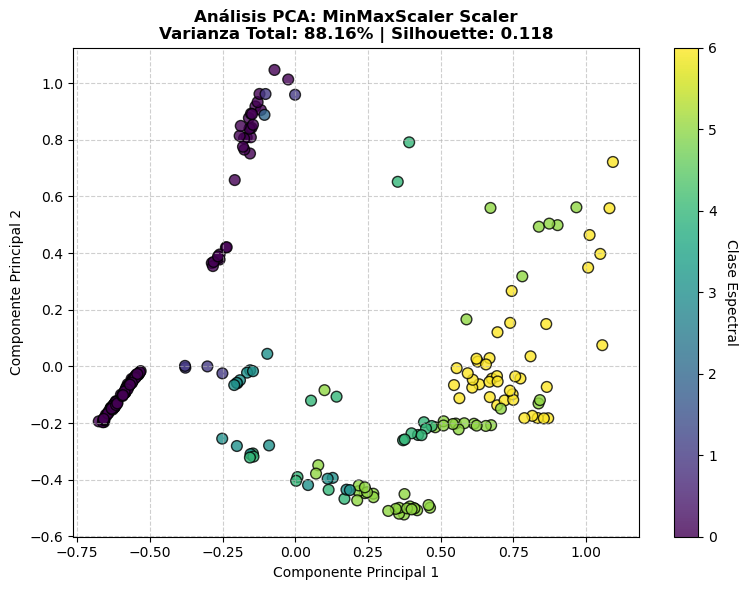

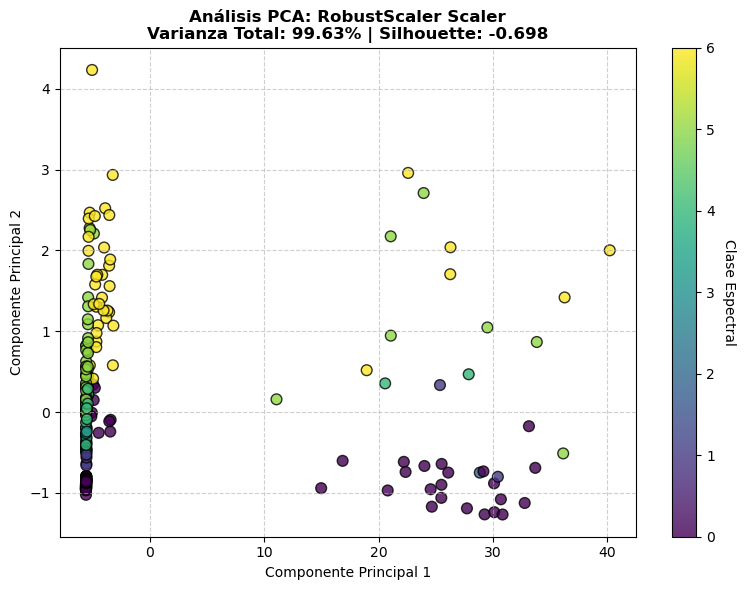

------------------------------
RESUMEN DE COMPARACIÓN:
StandardScaler: Varianza=83.79%, Silhouette=0.019
MinMaxScaler: Varianza=88.16%, Silhouette=0.118
RobustScaler: Varianza=99.63%, Silhouette=-0.698


In [138]:

# Diccionario para guardar el rendimiento de cada scaler
resultados_analisis = {}

# Definimos las clases reales para la leyenda (basado en tu dataframe original)
nombres_clases = data_df['Spectral_Class'].unique() # Asegúrate de usar el df con texto

for name, scaler in scalers.items():
    # 1. Pipeline: Escalado + PCA
    pipeline = Pipeline([
        ('scaler', scaler),
        ('pca', PCA(n_components=2, random_state=SEMILLA))
    ])

    X_pca = pipeline.fit_transform(X)
    pca_obj = pipeline.named_steps['pca']
    
    # Cálculo de Varianza
    total_explained = np.sum(pca_obj.explained_variance_ratio_)
    
    # Métrica Silhouette Score
    score_sil = silhouette_score(X_pca, y_numerico)
    
    # Guardamos para comparar luego
    resultados_analisis[name] = {'varianza': total_explained, 'silhouette': score_sil}

    # Graficado
    plt.figure(figsize=(8, 6))
    
    # Scatter plot
    scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_numerico, cmap='viridis', edgecolor='k', s=60, alpha=0.8)
    
    # Añadimos barra de colores con nombres de las clases
    cbar = plt.colorbar(scatter)
    cbar.set_label('Clase Espectral', rotation=270, labelpad=15)
    
    # Título dinámico con métricas
    plt.title(f'Análisis PCA: {name} Scaler\n'
              f'Varianza Total: {total_explained:.2%} | Silhouette: {score_sil:.3f}', 
              fontsize=12, fontweight='bold')
    
    plt.xlabel('Componente Principal 1')
    plt.ylabel('Componente Principal 2')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

# Resumen de resultados
print("-" * 30)
print("RESUMEN DE COMPARACIÓN:")
for s, m in resultados_analisis.items():
    print(f"{s}: Varianza={m['varianza']:.2%}, Silhouette={m['silhouette']:.3f}")

FALTA POR DECIR XQ ESTE ESCALADO##########################################

In [139]:
# Escalado con MinMax
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Reducción con PCA a 2 componentes
pca = PCA(n_components=2, random_state=SEMILLA)
X_pca = pca.fit_transform(X_scaled)

# K-means

Primero medimos el numero de clusters

In [140]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

inertia = []
silhouette = []
K = range(2, 10)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=SEMILLA)
    kmeans.fit(X_pca)
    inertia.append(kmeans.inertia_)
    silhouette.append(silhouette_score(X_pca, kmeans.labels_))





Medimos la inercia mediante el metodo del codo

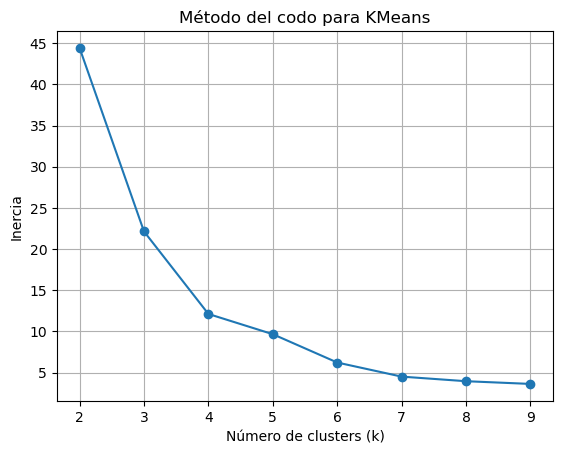

In [141]:
# Gráfico del método del codo
plt.figure()
plt.plot(K, inertia, 'o-')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inercia')
plt.title('Método del codo para KMeans')
plt.grid()
plt.show()

Y la distancia entre un cluster y otro por medio del coeficiente de silueta

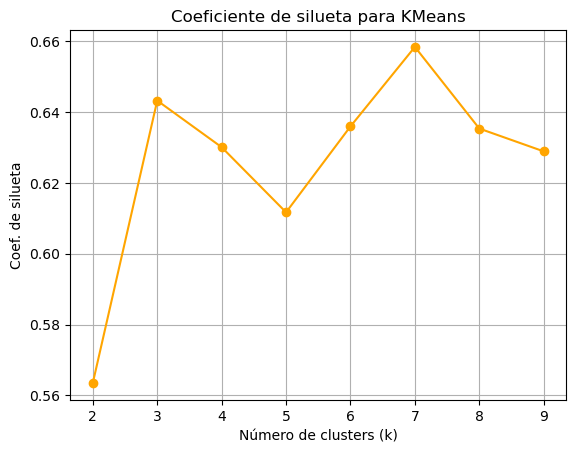

k   |  silhouette
------------------
 2  |  0.5635
 3  |  0.6432
 4  |  0.6301
 5  |  0.6117
 6  |  0.6359
 7  |  0.6584
 8  |  0.6353
 9  |  0.6289

Silhouette para k = 3 → 0.6432
Máximo global: k = 7  (silhouette = 0.6584)


In [142]:
# Gráfico del coeficiente de silueta
plt.figure()
plt.plot(K, silhouette, 'o-', color='orange')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Coef. de silueta')
plt.title('Coeficiente de silueta para KMeans')
plt.grid()
plt.show()


print("k   |  silhouette")
print("------------------")
for k, sil in zip(K, silhouette):
    print(f"{k:>2}  |  {sil:.4f}")

# · Silhouette concreta para k = 3
sil_k3 = silhouette[K.index(3)]
print(f"\nSilhouette para k = 3 → {sil_k3:.4f}")

# · Mejor k según la métrica
best_idx = np.argmax(silhouette)
print(f"Máximo global: k = {K[best_idx]}  (silhouette = {silhouette[best_idx]:.4f})")


Aunque el valor más alto del coeficiente de silueta se obtiene con k=7, el método del codo muestra claramente un punto de inflexión en k=4, donde la inercia comienza a disminuir.

Además, el valor de silueta en k=4 sigue siendo razonablemente alto, lo que sugiere una buena separación entre los clusters. Por tanto, optamos por aplicar KMeans con k=3

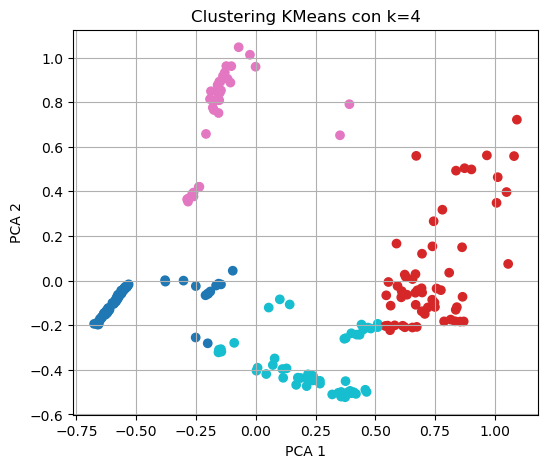

In [143]:
k_opt = 4

kmeans = KMeans(n_clusters=k_opt, random_state=SEMILLA)
kmeans_labels = kmeans.fit_predict(X_pca)

# Visualizar los clusters encontrados
plt.figure(figsize=(6, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='tab10')
plt.title(f'Clustering KMeans con k={k_opt}')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.grid()
plt.show()


# Clustering jerárquico / aglomerativo

Comparamos funciones de linkages con numeros de clusters para quedarnos con el mejor

In [ ]:
linkages = ['ward', 'complete', 'average', 'single']
k_range  = range(2, 7)
results  = []

for link in linkages:
    for k in k_range:
        labels = AgglomerativeClustering(n_clusters=k, linkage=link).fit_predict(X_pca)
        sil = silhouette_score(X_pca, labels) if len(np.unique(labels)) > 1 else np.nan
        results.append((link, k, sil))

res_df = pd.DataFrame(results, columns=['linkage', 'k', 'silhouette'])
best_link, best_k = res_df.loc[res_df['silhouette'].idxmax(), ['linkage', 'k']]

print(f"Mejor -> linkage = {best_link}, k = {best_k}, silhouette = "
      f"{res_df['silhouette'].max():.4f}")
display(res_df.pivot(index='linkage', columns='k', values='silhouette'))


Mejor → linkage = ward, k = 3, silhouette = 0.6374


k,2,3,4,5,6
linkage,,,,,
average,0.556043,0.637420,0.612136,0.594001,0.611222
complete,0.439456,0.484476,0.605719,0.616611,0.607083
single,0.368801,0.270955,0.113009,-0.097778,-0.148720
ward,0.556043,0.637420,0.605772,0.626546,0.635349


Optamos por el linkage ward con k = 3 clusters.

Hemos determinado que k=3 es la opción óptima para K-Means porque representa el punto de equilibrio donde la inercia se estabiliza, maximizando la cohesión interna sin segmentar artificialmente los datos. Por otro lado, se seleccionó el enlace 'Ward' para el clustering jerárquico debido a su capacidad para generar agrupaciones compactas y minimizar la varianza interna, superando a otros métodos que tendían a crear grupos dispersos o encadenados.

Ahora mostramos en una gráfica cómo se han agrupado los datos:

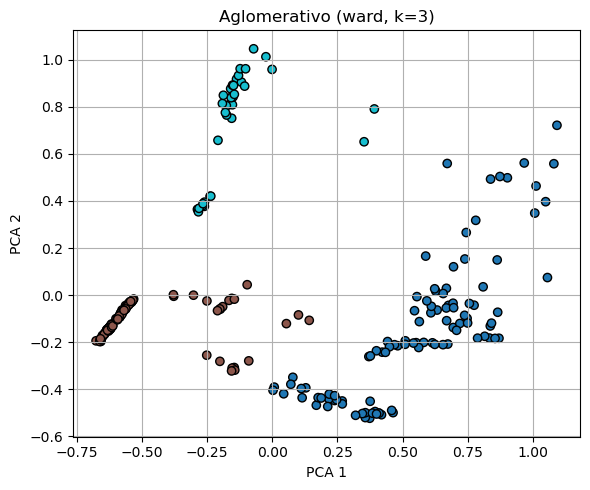

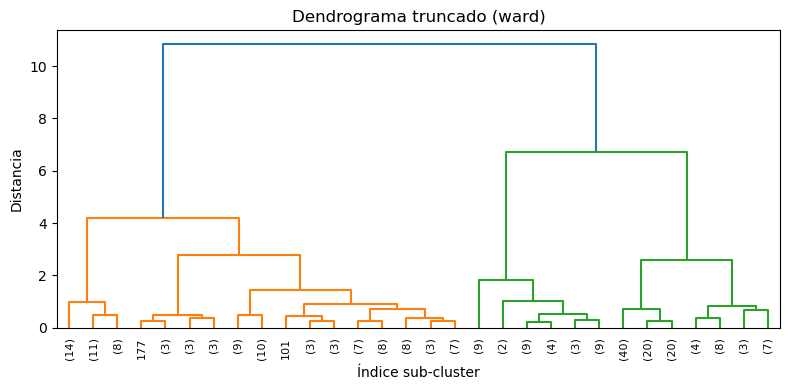

In [145]:

best_labels = AgglomerativeClustering(n_clusters=best_k, linkage=best_link).fit_predict(X_pca)

plt.figure(figsize=(6, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=best_labels, cmap='tab10', edgecolor='k')
plt.title(f'Aglomerativo ({best_link}, k={best_k})')
plt.xlabel('PCA 1'); plt.ylabel('PCA 2'); plt.grid(); plt.tight_layout()
plt.show()

Z = linkage(X_pca, method=best_link)
plt.figure(figsize=(8, 4))
dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90., leaf_font_size=8.)
plt.title(f'Dendrograma truncado ({best_link})')
plt.xlabel('Índice sub-cluster'); plt.ylabel('Distancia'); plt.tight_layout()
plt.show()
